# Visualize the Education's Impact

In [1]:
import os, sys

sys.path.append(os.path.abspath("."))

In [2]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [3]:
CURRENT_ADDR

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article'

## Impact Package

In [4]:
import numpy as np
import os, sys
import pandas as pd

In [5]:
import LoadDataFromDisk
from VisualizeEffect import read_all_probs_df_from_parquet, visualize_factual_counterfactual_violin_plots
from VisualizeEffect import visualize_factual_counterfactual_violin_plots_stratification

## Function

## Run

In [9]:
if __name__ == '__main__':
    pass

In [10]:
os.makedirs(MLD01e1_RESULTS_ADDR := './MLD01e_Results/MLD01e1_Results/indirect', exist_ok=True)

In [11]:
probs_dictionary = read_all_probs_df_from_parquet(MLD01e1_RESULTS_ADDR)

In [12]:
input_name_list = ['factual_knowledge_probs', 'factual_awareness_probs', 
                   'factual_action_probs_soilandwater', 'factual_action_probs_riskreduction', 
                   'factual_action_probs_roadimprovement', 'factual_action_probs_communityparticipation']

In [13]:
os.makedirs(MLD01e1_FIGURE_ADDR := './MLD01e_Figures/indirect', exist_ok=True)

### Total Effect

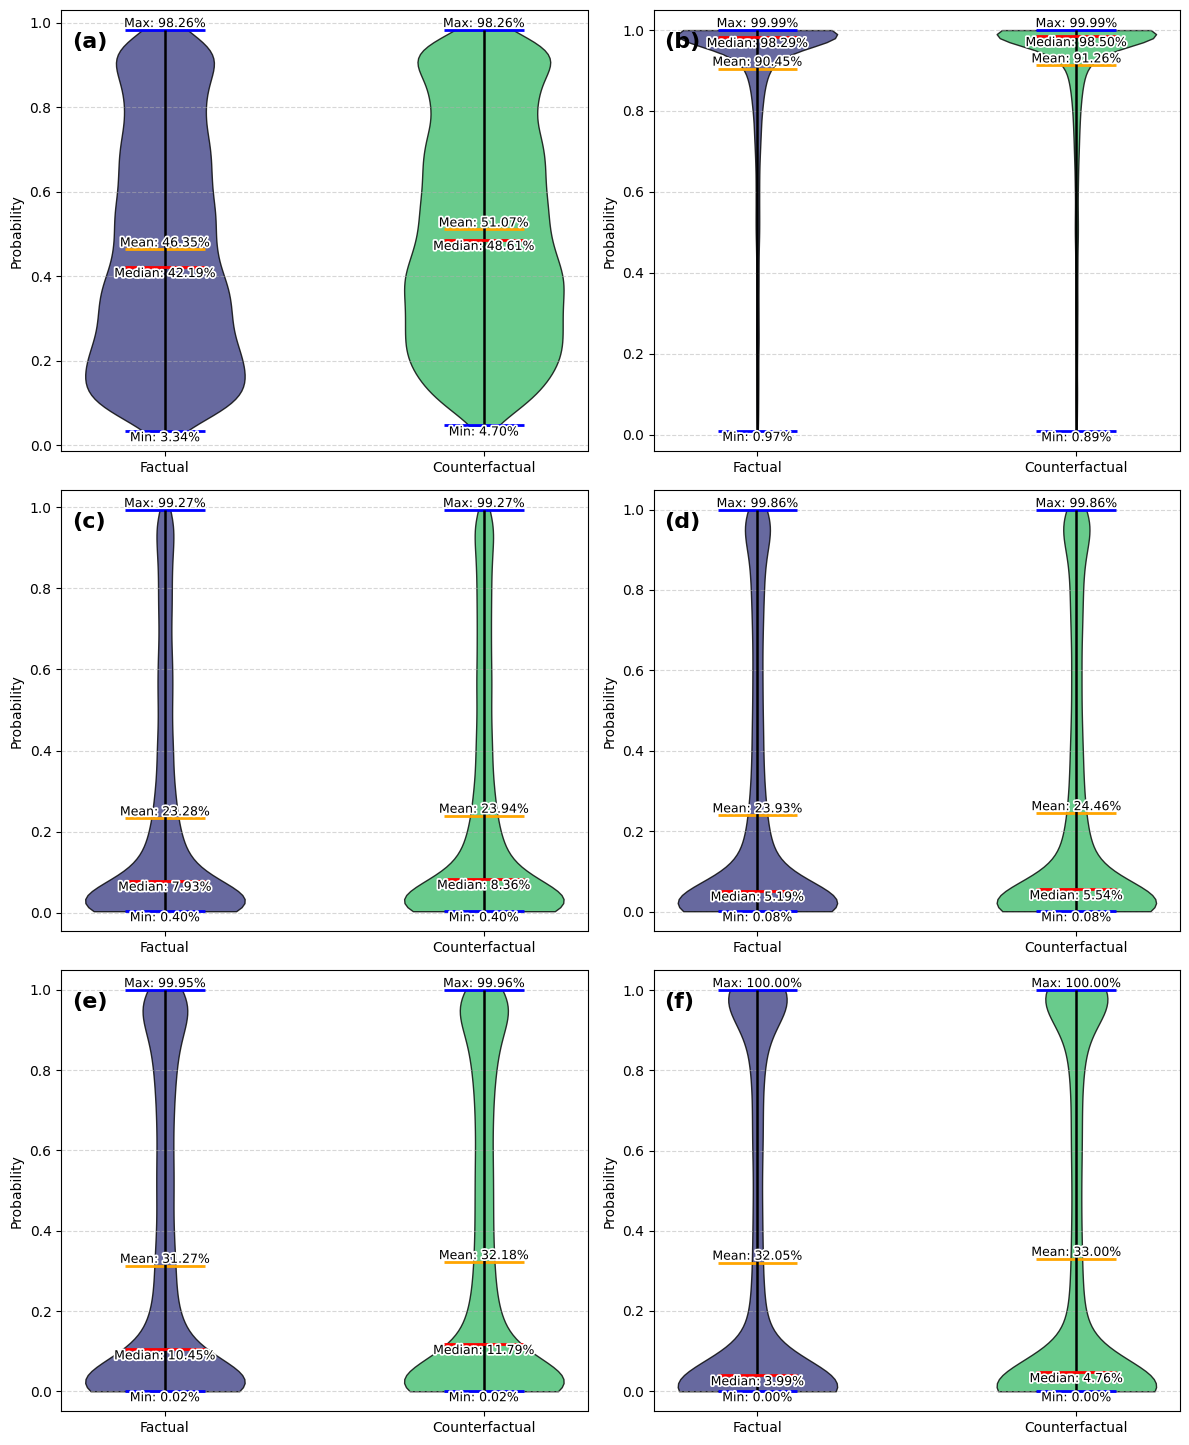

✅ Violin plots saved to: ./MLD01e_Figures/indirect/FigureXX_factual_counterfactual_violin_plots.jpg


In [14]:
visualize_factual_counterfactual_violin_plots(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    save_address=f'{MLD01e1_FIGURE_ADDR}/FigureXX_factual_counterfactual_violin_plots.jpg'
    )

### Visualize Gender effect

In [15]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Female']].reset_index(drop=True)

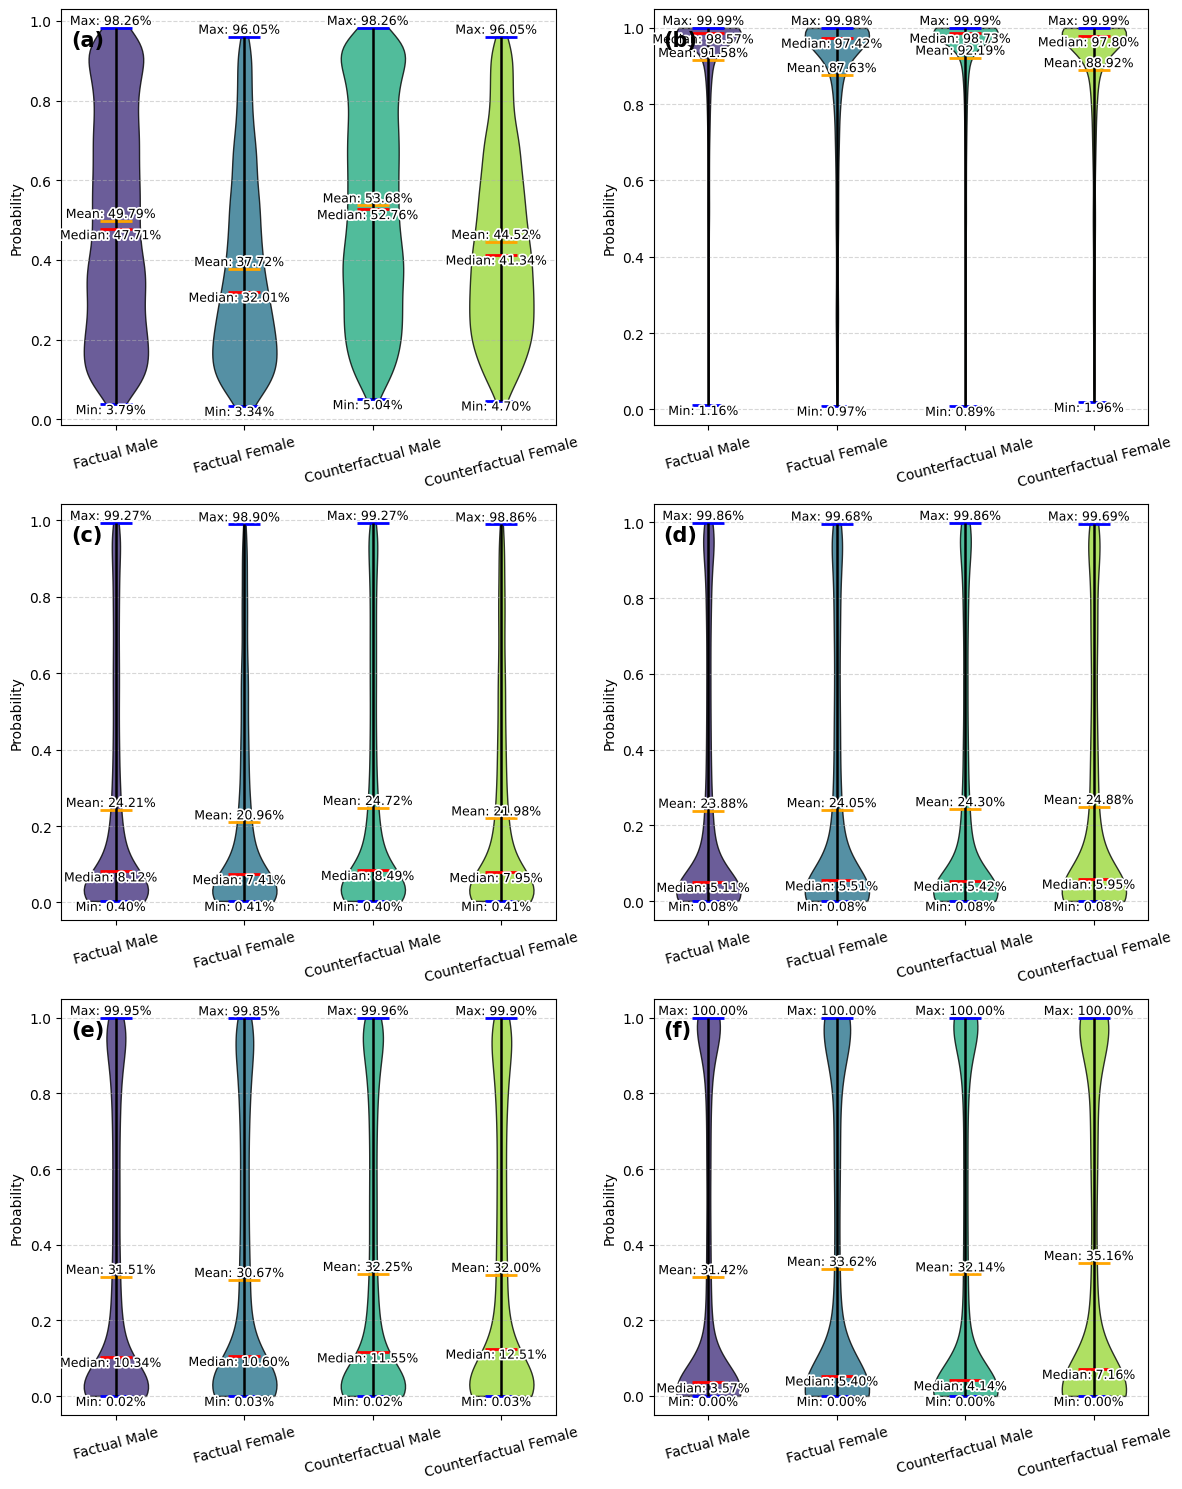

✅ Violin plots saved to: ./MLD01e_Figures/indirect/FigureXX_factual_counterfactual_violin_stratification_gender.jpg


In [16]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Male', 'Factual Female', 'Counterfactual Male', 'Counterfactual Female'],
    save_address=f'{MLD01e1_FIGURE_ADDR}/FigureXX_factual_counterfactual_violin_stratification_gender.jpg'
    )

### Visualize Senior

In [17]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [18]:
print(df_all.columns[:40])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')


In [19]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Age']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['Above65_Dummy'] = (df_stratification['Respon_Age'] > 65).astype(int)
df_stratification = df_stratification[['Above65_Dummy']]

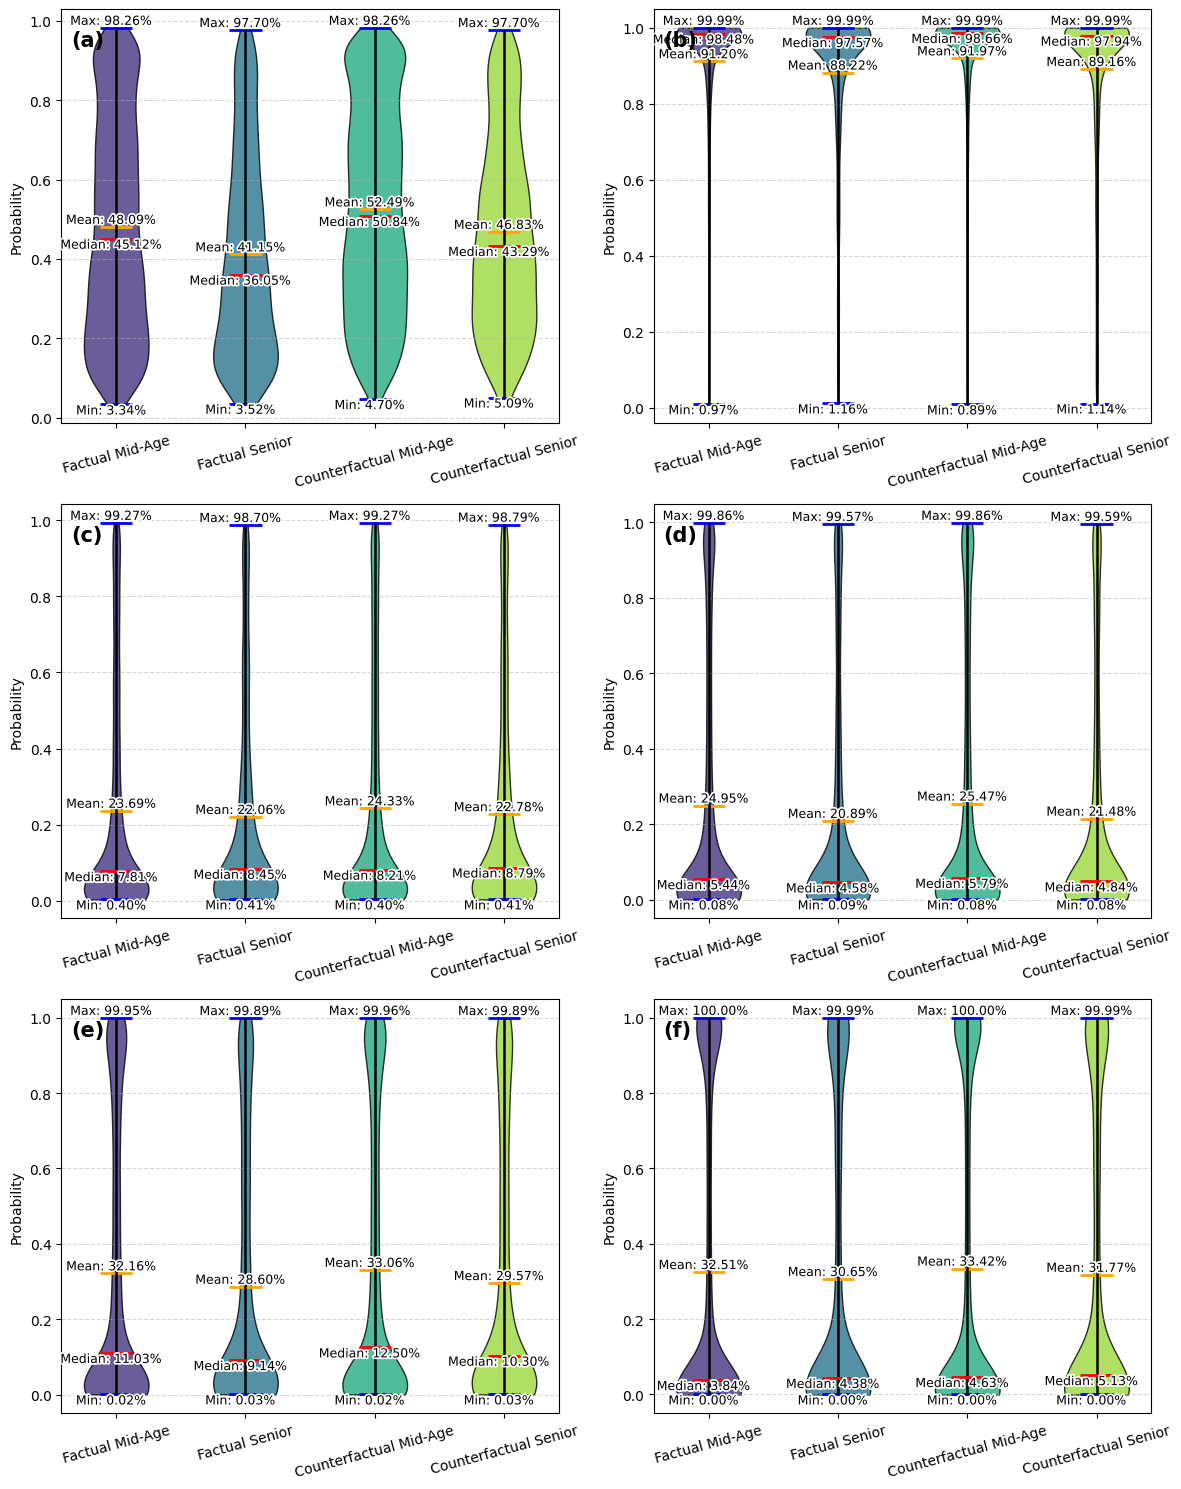

✅ Violin plots saved to: ./MLD01e_Figures/indirect/FigureXX_factual_counterfactual_violin_stratification_senior.jpg


In [20]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Mid-Age', 'Factual Senior', 'Counterfactual Mid-Age', 'Counterfactual Senior'],
    save_address=f'{MLD01e1_FIGURE_ADDR}/FigureXX_factual_counterfactual_violin_stratification_senior.jpg'
    )

### Visualize Rural effect

In [21]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Rural_Dummy']].reset_index(drop=True)

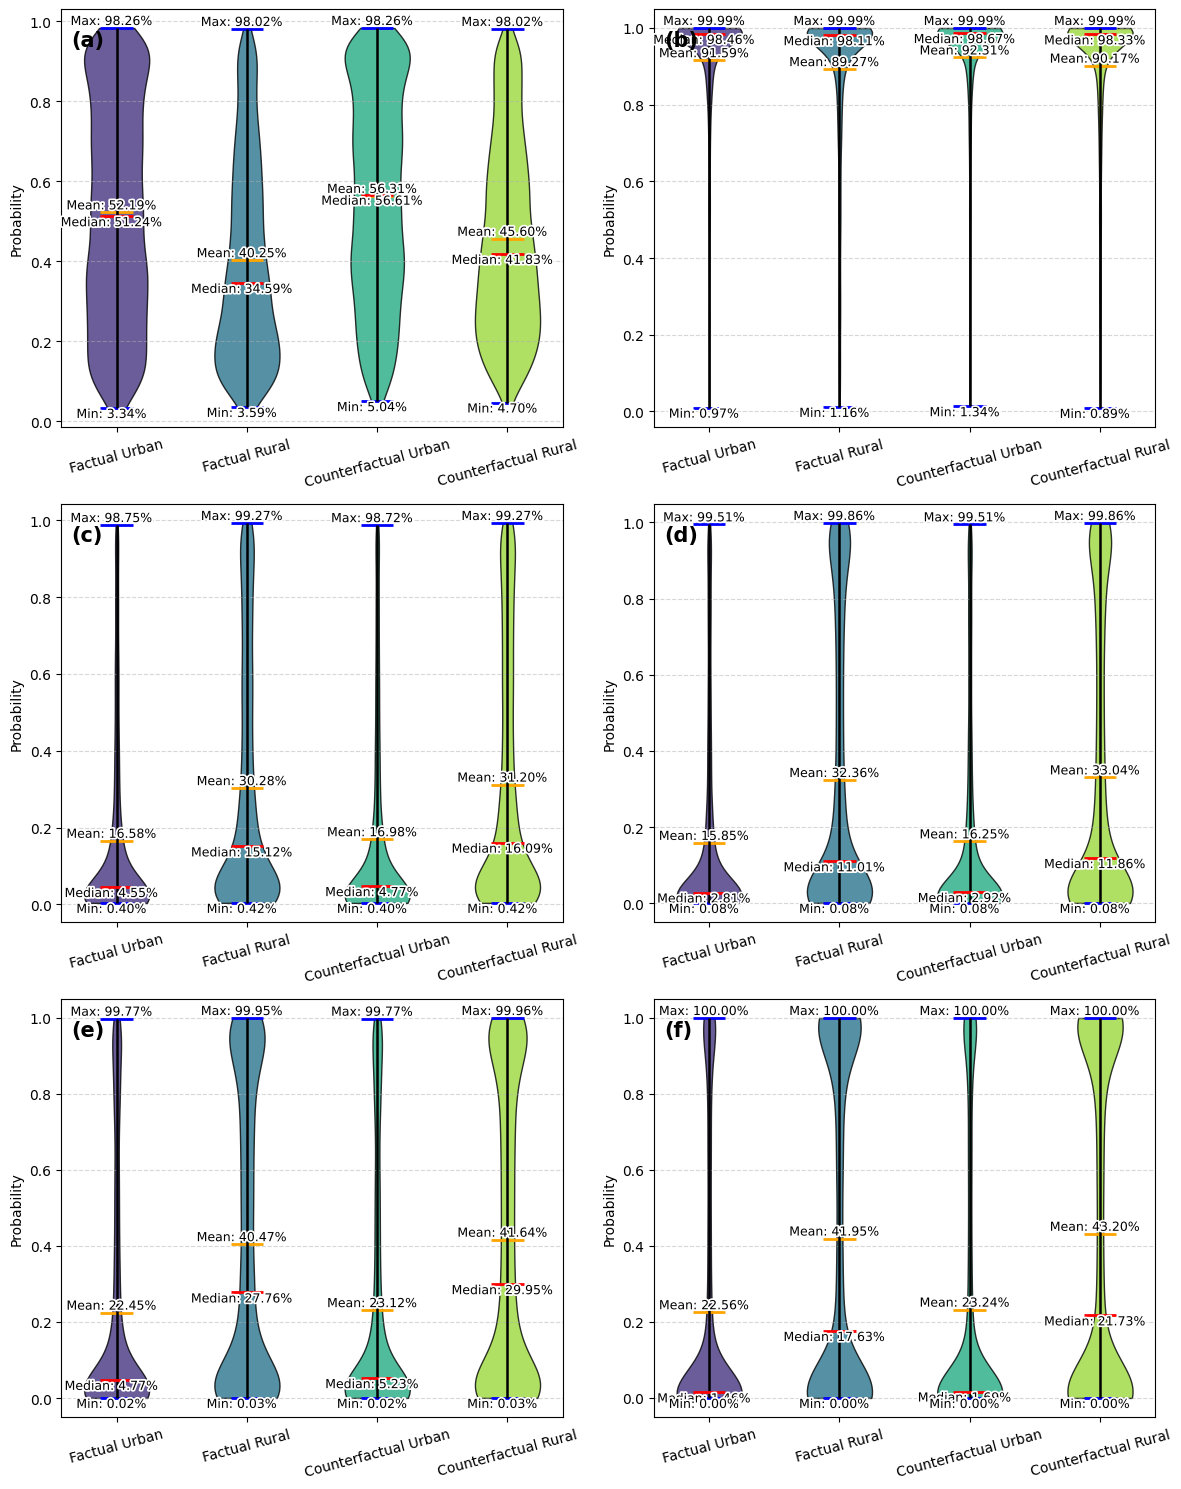

✅ Violin plots saved to: ./MLD01e_Figures/indirect/FigureXX_factual_counterfactual_violin_stratification_rural.jpg


In [22]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Urban', 'Factual Rural', 'Counterfactual Urban', 'Counterfactual Rural'],
    save_address=f'{MLD01e1_FIGURE_ADDR}/FigureXX_factual_counterfactual_violin_stratification_rural.jpg'
    )

### Visualize Total Income

In [23]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [24]:
df_all['TotalIncome'].describe()

count    1.156800e+04
mean     3.239423e+05
std      1.143592e+06
min      0.000000e+00
25%      5.400000e+04
50%      1.700000e+05
75%      4.000000e+05
max      9.920000e+07
Name: TotalIncome, dtype: float64

In [25]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['TotalIncome']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['HighIncome_Dummy'] = (df_stratification['TotalIncome'] > 1.700000e+05).astype(int)
df_stratification = df_stratification[['HighIncome_Dummy']]

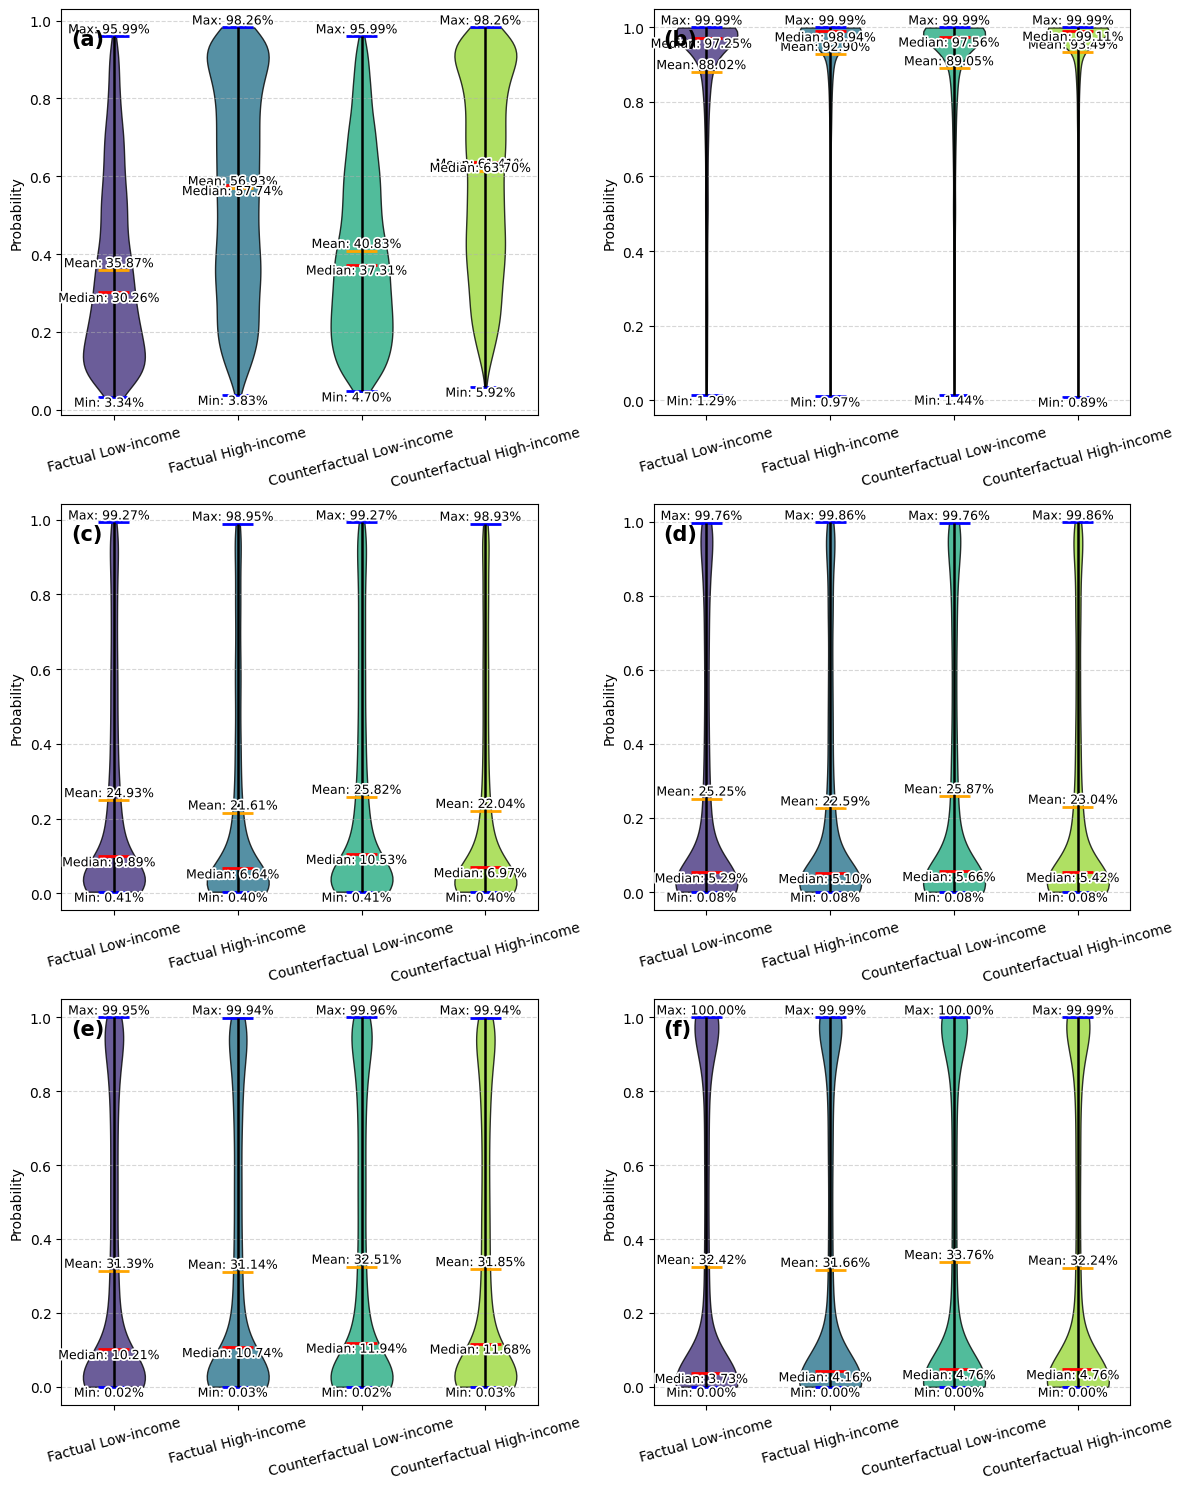

✅ Violin plots saved to: ./MLD01e_Figures/indirect/FigureXX_factual_counterfactual_violin_stratification_income.jpg


In [26]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Low-income', 'Factual High-income', 'Counterfactual Low-income', 'Counterfactual High-income'],
    save_address=f'{MLD01e1_FIGURE_ADDR}/FigureXX_factual_counterfactual_violin_stratification_income.jpg'
    )